In [6]:
import gzip
import json
import os
import random
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np


In [7]:
input_path = "/content/Wiki-Vote.txt"
outdir = "/content/output"


In [8]:
def load_snap_digraph(path):
    G = nx.DiGraph()


    if path.endswith(".gz"):
        f = gzip.open(path, "rt", encoding="utf-8", errors="ignore")
    else:
        f = open(path, "r", encoding="utf-8", errors="ignore")

    with f:
        for line in f:

            if not line.strip() or line.startswith("#"):
                continue

            parts = line.strip().split()
            if len(parts) < 2:
                continue

            u = int(parts[0])
            v = int(parts[1])
            G.add_edge(u, v)

    return G


In [9]:
def load_snap_digraph(path):
    G = nx.DiGraph()

    if path.endswith(".gz"):
        f = gzip.open(path, "rt", encoding="utf-8", errors="ignore")
    else:
        f = open(path, "r", encoding="utf-8", errors="ignore")

    with f:
        for line in f:
            if not line.strip() or line.startswith("#"):
                continue

            parts = line.strip().split()
            if len(parts) < 2:
                continue

            u = int(parts[0])
            v = int(parts[1])
            G.add_edge(u, v)

    return G

In [10]:
def plot_degree_distribution(counter, title, filename):
    x = sorted([k for k in counter.keys() if k > 0])
    y = [counter[k] for k in x]

    plt.figure(figsize=(7, 5))
    plt.scatter(x, y, s=15)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, filename), dpi=200)
    plt.show()
    plt.close()


def plot_top_centrality(values_dict, title, filename, top_n=10):
    top_items = sorted(values_dict.items(), key=lambda x: x[1], reverse=True)[:top_n]

    labels = [str(node) for node, value in top_items]
    values = [value for node, value in top_items]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, values)
    plt.xticks(rotation=45)
    plt.ylabel("Score")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, filename), dpi=200)
    plt.show()
    plt.close()

In [11]:
def graph_summary_undirected(G):
    largest_component = G.subgraph(max(nx.connected_components(G), key=len)).copy()

    summary = {
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "density": nx.density(G),
        "average_clustering": nx.average_clustering(G),
        "largest_component_nodes": largest_component.number_of_nodes(),
        "approx_average_path_length": approx_average_shortest_path_length(largest_component, sample_size=75)
    }

    return summary


def benchmark_graphs(n, avg_degree, seed=42):
    p = avg_degree / (n - 1) if n > 1 else 0

    ba_m = max(1, round(avg_degree / 2))
    ba_m = min(ba_m, max(1, n - 1))

    ws_k = max(2, int(round(avg_degree)))
    if ws_k % 2 == 1:
        ws_k += 1
    if ws_k >= n:
        ws_k = n - 1
    if ws_k % 2 == 1:
        ws_k -= 1
    if ws_k < 2 and n > 2:
        ws_k = 2

    graphs = {}
    graphs["ER"] = nx.gnp_random_graph(n, p, seed=seed)
    graphs["BA"] = nx.barabasi_albert_graph(n, ba_m, seed=seed)

    if n > 2 and ws_k >= 2:
        graphs["WS"] = nx.watts_strogatz_graph(n, ws_k, 0.1, seed=seed)
    else:
        H = nx.Graph()
        H.add_nodes_from(range(n))
        graphs["WS"] = H

    return graphs

In [12]:
G = load_snap_digraph(input_path)

if G.number_of_nodes() == 0:
    raise ValueError("Graph is empty. Check the file path and uploaded file name.")

print("Graph loaded successfully")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Graph loaded successfully
Number of nodes: 7115
Number of edges: 103689


In [13]:
results = {}

results["basic"] = {
    "nodes": G.number_of_nodes(),
    "edges": G.number_of_edges(),
    "density_directed": nx.density(G),
    "self_loops": nx.number_of_selfloops(G),
    "reciprocity": nx.reciprocity(G)
}

results["basic"]

{'nodes': 7115,
 'edges': 103689,
 'density_directed': 0.0020485375110809584,
 'self_loops': 0,
 'reciprocity': 0.0564572905515532}

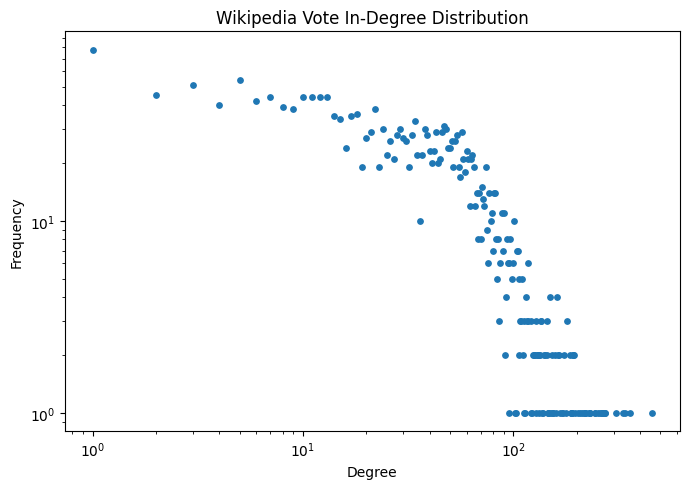

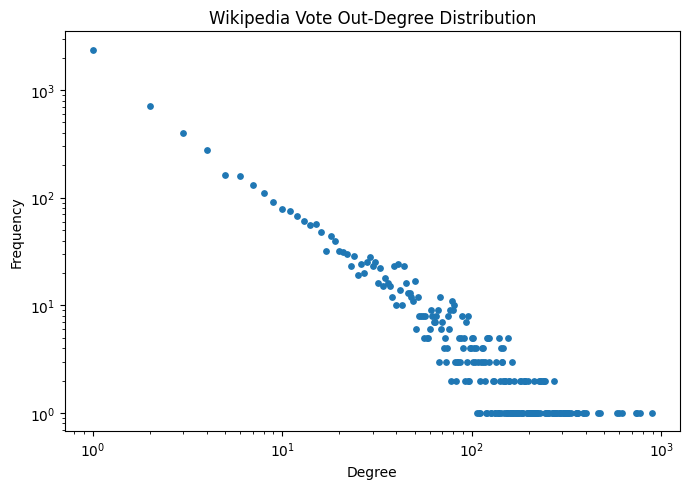

In [14]:
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

plot_degree_distribution(
    Counter(in_degrees.values()),
    "Wikipedia Vote In-Degree Distribution",
    "in_degree_distribution.png"
)

plot_degree_distribution(
    Counter(out_degrees.values()),
    "Wikipedia Vote Out-Degree Distribution",
    "out_degree_distribution.png"
)

In [15]:
wcc_sizes = sorted([len(c) for c in nx.weakly_connected_components(G)], reverse=True)
scc_sizes = sorted([len(c) for c in nx.strongly_connected_components(G)], reverse=True)

results["components"] = {
    "number_of_weakly_connected_components": len(wcc_sizes),
    "number_of_strongly_connected_components": len(scc_sizes),
    "largest_wcc_size": wcc_sizes[0],
    "largest_scc_size": scc_sizes[0],
    "top_10_wcc_sizes": wcc_sizes[:10],
    "top_10_scc_sizes": scc_sizes[:10]
}

results["components"]

{'number_of_weakly_connected_components': 24,
 'number_of_strongly_connected_components': 5816,
 'largest_wcc_size': 7066,
 'largest_scc_size': 1300,
 'top_10_wcc_sizes': [7066, 3, 3, 3, 2, 2, 2, 2, 2, 2],
 'top_10_scc_sizes': [1300, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [16]:
Gw = largest_wcc_subgraph(G)
Gs = largest_scc_subgraph(G)

Gw_undirected = Gw.to_undirected()
Gs_undirected = Gs.to_undirected()

try:
    diameter_approx = nx.approximation.diameter(Gw_undirected)
except Exception as e:
    diameter_approx = str(e)

results["paths"] = {
    "largest_wcc_approx_average_path_length": approx_average_shortest_path_length(Gw_undirected, sample_size=100),
    "largest_wcc_approx_diameter": diameter_approx,
    "largest_scc_approx_average_path_length": approx_average_shortest_path_length(Gs_undirected, sample_size=100)
}

results["paths"]

{'largest_wcc_approx_average_path_length': 3.265782024062279,
 'largest_wcc_approx_diameter': 7,
 'largest_scc_approx_average_path_length': 2.2351963048498846}

In [17]:
G_undirected = G.to_undirected()

results["structure"] = {
    "average_clustering": nx.average_clustering(G_undirected),
    "directed_density": nx.density(G),
    "undirected_density": nx.density(G_undirected),
    "number_of_triangles": int(sum(nx.triangles(G_undirected).values()) // 3)
}

results["structure"]

{'average_clustering': 0.1408978458930873,
 'directed_density': 0.0020485375110809584,
 'undirected_density': 0.003981420144693063,
 'number_of_triangles': 608389}

In [18]:
print("Calculating centrality measures...")

in_degree_centrality = nx.in_degree_centrality(Gw)
out_degree_centrality = nx.out_degree_centrality(Gw)
pagerank = nx.pagerank(Gw, alpha=0.85)

betweenness = nx.betweenness_centrality(Gw, k=min(300, Gw.number_of_nodes()), seed=42)

sample_nodes = list(Gw.nodes())[:1000]
closeness = {node: nx.closeness_centrality(Gw, u=node) for node in sample_nodes}

results["centrality_top10"] = {
    "in_degree": sorted(in_degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10],
    "out_degree": sorted(out_degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10],
    "pagerank": sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10],
    "betweenness": sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10],
    "closeness": sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]
}

results["centrality_top10"]

Calculating centrality measures...


{'in_degree': [(4037, 0.06468506723283794),
  (15, 0.05109695682944091),
  (2398, 0.048124557678697805),
  (2625, 0.046850672328379334),
  (1297, 0.04373673036093419),
  (2565, 0.03878273177636235),
  (762, 0.03849964614295825),
  (2328, 0.037650389242745934),
  (5254, 0.03750884642604388),
  (3352, 0.037367303609341825)],
 'out_degree': [(2565, 0.12639773531493276),
  (766, 0.10941259731068649),
  (11, 0.10516631280962492),
  (457, 0.10360934182590234),
  (2688, 0.08747346072186837),
  (1166, 0.08478414720452937),
  (1549, 0.08308563340410474),
  (1151, 0.06680820948336873),
  (1374, 0.0653927813163482),
  (1133, 0.0564755838641189)],
 'pagerank': [(4037, 0.00462885637592016),
  (15, 0.0036943681502668493),
  (6634, 0.0035379784698800136),
  (2625, 0.0032981996394484286),
  (2398, 0.0026147772630201096),
  (2470, 0.0025389314315944923),
  (2237, 0.0025133983484059304),
  (4191, 0.0022743221946779357),
  (7553, 0.0021780953649744995),
  (5254, 0.0021576894283344555)],
 'betweenness': [

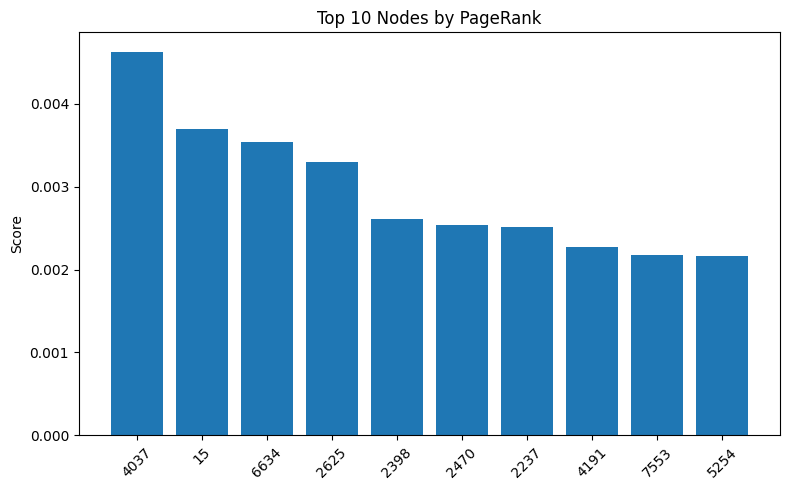

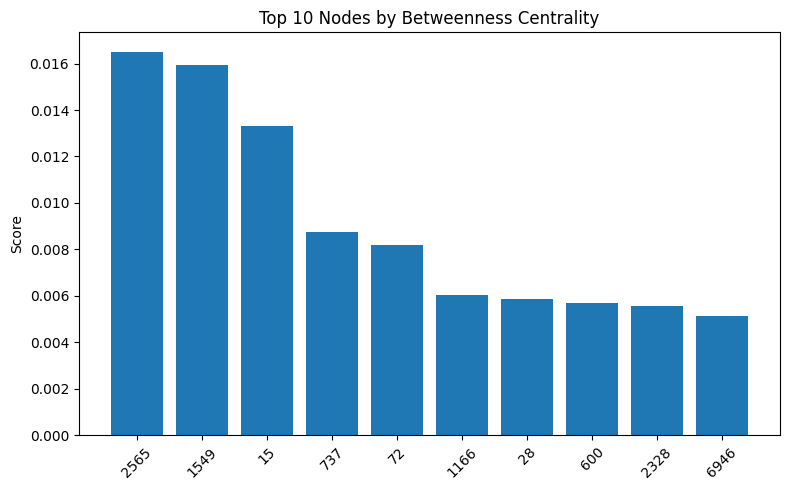

In [19]:
plot_top_centrality(
    pagerank,
    "Top 10 Nodes by PageRank",
    "pagerank_top10.png"
)

plot_top_centrality(
    betweenness,
    "Top 10 Nodes by Betweenness Centrality",
    "betweenness_top10.png"
)

In [20]:
average_degree = np.mean([d for node, d in G_undirected.degree()])

benchmark = benchmark_graphs(G_undirected.number_of_nodes(), average_degree, seed=42)

results["benchmarks"] = {
    "real_network": graph_summary_undirected(G_undirected)
}

for name, graph in benchmark.items():
    results["benchmarks"][name] = graph_summary_undirected(graph)

results["benchmarks"]

{'real_network': {'nodes': 7115,
  'edges': 100762,
  'density': 0.003981420144693063,
  'average_clustering': 0.1408978458930873,
  'largest_component_nodes': 7066,
  'approx_average_path_length': 3.2649945741920265},
 'ER': {'nodes': 7115,
  'edges': 100406,
  'density': 0.003967353476985885,
  'average_clustering': 0.003983278997135465,
  'largest_component_nodes': 7115,
  'approx_average_path_length': 2.943161840502296},
 'BA': {'nodes': 7115,
  'edges': 99414,
  'density': 0.003928156470341162,
  'average_clustering': 0.018027695664568442,
  'largest_component_nodes': 7115,
  'approx_average_path_length': 2.810405772654859},
 'WS': {'nodes': 7115,
  'edges': 99610,
  'density': 0.003935901040202418,
  'average_clustering': 0.5272952922689531,
  'largest_component_nodes': 7115,
  'approx_average_path_length': 3.6903739105988196}}

In [21]:
results_file = os.path.join(outdir, "results.json")

with open(results_file, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print("Analysis complete")
print("Results saved to:", results_file)
print("Plots saved in:", outdir)

Analysis complete
Results saved to: /content/output/results.json
Plots saved in: /content/output


In [22]:
print(json.dumps(results, indent=2))

{
  "basic": {
    "nodes": 7115,
    "edges": 103689,
    "density_directed": 0.0020485375110809584,
    "self_loops": 0,
    "reciprocity": 0.0564572905515532
  },
  "components": {
    "number_of_weakly_connected_components": 24,
    "number_of_strongly_connected_components": 5816,
    "largest_wcc_size": 7066,
    "largest_scc_size": 1300,
    "top_10_wcc_sizes": [
      7066,
      3,
      3,
      3,
      2,
      2,
      2,
      2,
      2,
      2
    ],
    "top_10_scc_sizes": [
      1300,
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1
    ]
  },
  "paths": {
    "largest_wcc_approx_average_path_length": 3.265782024062279,
    "largest_wcc_approx_diameter": 7,
    "largest_scc_approx_average_path_length": 2.2351963048498846
  },
  "structure": {
    "average_clustering": 0.1408978458930873,
    "directed_density": 0.0020485375110809584,
    "undirected_density": 0.003981420144693063,
    "number_of_triangles": 608389
  },
  "centrality_top